# Classificador DoS SOME/IP — Pipeline Completo

Notebook de reproducao completa: do PCAP bruto ate as metricas finais.

**Ataque**: DoS *NOTIFICATION flood* — IP atacante `172.18.0.11`  
**Referencia**: Kim et al. (2026). XGBoost-Based Anomaly Detection for SOME/IP. Systems 14(2), 196.

In [1]:
import sys, subprocess, time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

DOS_DIR   = Path().resolve()          # detection/dos/
DET_DIR   = DOS_DIR.parent            # detection/
SRC_DIR   = DET_DIR / 'src'
PARSE_DIR = DET_DIR / 'data' / 'parsed'
RAW_DIR   = DET_DIR / 'data' / 'raw'
DATA_DIR  = DOS_DIR / 'data'
MODEL_DIR = DOS_DIR / 'model'

sys.path.insert(0, str(DET_DIR))

FEAT_COLS = [
    'f01_ip_time_interval', 'f08_someip_payload_change',
    'f11_ip_length_change', 'f12_tcpudp_length_change',
    'f13_payload_repeat_rate', 'f15_someip_payload_len',
    'f16_tcpudp_len', 'f17_src_packet_rate', 'f18_src_payload_diversity',
]
FEAT_LABELS = [
    'f01 ip_time_interval', 'f08 payload_hamming',
    'f11 ip_len_change', 'f12 tcpudp_len_change',
    'f13 payload_repeat', 'f15 someip_payload_len',
    'f16 tcpudp_len', 'f17 src_packet_rate', 'f18 payload_diversity',
]

PCAP_FILES = ['benign_traffic.pcap', 'dos_noti_flood.pcap']
ATTACKER   = '172.18.0.11'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Ambiente configurado.')
print(f'  detection/ : {DET_DIR}')
print(f'  dos/       : {DOS_DIR}')

Ambiente configurado.
  detection/ : C:\Mestrado\SDV_Research\detection
  dos/       : C:\Mestrado\SDV_Research\detection\dos


## 1. Dataset e Cenarios de Ataque

### 1.1 Visao geral do dataset

O dataset foi coletado em uma rede SOME/IP composta por **nove ECUs** comunicando-se
via arquitetura **publish-subscribe**. Quando um evento e gerado, os dados sao entregues
dinamicamente aos ECUs inscritos. O trafego e distribuido no formato PCAP.

Fonte: Figshare 30970450 — Kim et al. (2026)

### 1.2 Cenario normal — `benign_traffic.pcap`

O trafego normal foi capturado sob condicoes de operacao benignas.
As ECUs se comunicam pela arquitetura publish-subscribe do SOME/IP:
mediante geracao de evento, os dados sao entregues dinamicamente
aos ECUs inscritos. Nenhum IP atacante esta presente neste PCAP (`label=0` em todos os pacotes).

### 1.3 Cenario de ataque — `dos_noti_flood.pcap`

**Tipo**: Denial-of-Service (DoS) por *Event Notification Flooding*

Este cenario modela um no in-vehicle malicioso que degrada a disponibilidade
da rede e das ECUs gerando um volume anormalmente alto de notificacoes de eventos
de servico em uma janela de tempo curta. Diferente de ataques furtivos que tentam
imitar o comportamento periodico normal, o atacante prioriza a **amplificacao de trafego**
para induzir:

- Congestionamento de rede
- Acumulo de filas (*queue buildup*)
- Sobrecarga de processamento nas ECUs receptoras

Como resultado, mensagens legitimas podem sofrer aumento de latencia, jitter ou perda,
e a pressao sobre CPU e buffers dos receptores pode aumentar significativamente.

**Parametros do ataque (IP atacante: `172.18.0.11`)**:

| Campo SOME/IP | Valor | Descricao |
|--------------|-------|-----------|
| `service_id` | `0x1001` | Servico alvo do flood |
| `instance_id` | `0x0001` | Instancia do servico |
| `method_id` | `0x0001` | Event ID 0x0001 (notificacoes usam method_id) |
| Volume | 3.000 notificacoes | Enviadas em loop fechado (*as fast as possible*) |

### 1.4 PCAPs utilizados neste experimento

In [2]:
print('=== Arquivos PCAP ===')
for name in PCAP_FILES:
    p = RAW_DIR / name
    if p.exists():
        print(f'  {name:<45}  {p.stat().st_size/1e6:>7.1f} MB  [OK]')
    else:
        print(f'  {name:<45}  NAO ENCONTRADO')

=== Arquivos PCAP ===
  benign_traffic.pcap                              223.3 MB  [OK]
  dos_noti_flood.pcap                              194.8 MB  [OK]


## 2. Parser — PCAP para CSV

O parser (Scapy) extrai campos IP, TCP/UDP e SOME/IP de cada pacote.
Rotula `label=1` para pacotes cujo `src_ip` pertence ao conjunto de atacantes do PCAP,
`label=0` para todo o restante.

Cada PCAP gera um CSV independente em `data/parsed/`.
Se o CSV ja existir, o passo e pulado automaticamente.

In [3]:
def run_script(script, *args, cwd=DET_DIR):
    cmd = [sys.executable, str(script), *args]
    print(f'Executando: {" ".join(str(c) for c in cmd)}')
    r = subprocess.run(cmd, cwd=str(cwd), capture_output=False, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'{script.name} falhou (exit {r.returncode})')

run_script(SRC_DIR / '01_parse.py',
           '--pcaps', 'benign_traffic.pcap', 'dos_noti_flood.pcap')

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\src\01_parse.py --pcaps benign_traffic.pcap dos_noti_flood.pcap


### 2.1 Distribuicao de pacotes por PCAP

In [4]:
pcap_stats = []
csv_map = {
    'benign_traffic.pcap': 'benign_traffic.csv',
    'dos_noti_flood.pcap': 'dos_noti_flood.csv',
}

for pcap_name, csv_name in csv_map.items():
    csv_path = PARSE_DIR / csv_name
    n_total = n_attack = 0
    for chunk in pd.read_csv(csv_path, usecols=['label'], chunksize=500_000):
        n_total  += len(chunk)
        n_attack += (chunk['label'] == 1).sum()
    n_normal = n_total - n_attack
    pcap_stats.append({
        'PCAP': pcap_name,
        'Total': n_total,
        'Normal (label=0)': n_normal,
        'Ataque (label=1)': n_attack,
        '% Ataque': f'{100*n_attack/n_total:.1f}%',
        'Tamanho CSV': f'{csv_path.stat().st_size/1e6:.0f} MB',
    })
    print(f'{pcap_name}')
    print(f'  Total   : {n_total:>10,}')
    print(f'  Normal  : {n_normal:>10,}  ({100*n_normal/n_total:.1f}%)')
    print(f'  Ataque  : {n_attack:>10,}  ({100*n_attack/n_total:.1f}%)')
    print()

df_stats = pd.DataFrame(pcap_stats)
display(df_stats.style.hide(axis='index'))

benign_traffic.pcap
  Total   :  2,193,802
  Normal  :  2,193,802  (100.0%)
  Ataque  :          0  (0.0%)



dos_noti_flood.pcap
  Total   :  1,864,530
  Normal  :  1,557,586  (83.5%)
  Ataque  :    306,944  (16.5%)



PCAP,Total,Normal (label=0),Ataque (label=1),% Ataque,Tamanho CSV
benign_traffic.pcap,2193802,2193802,0,0.0%,506 MB
dos_noti_flood.pcap,1864530,1557586,306944,16.5%,446 MB


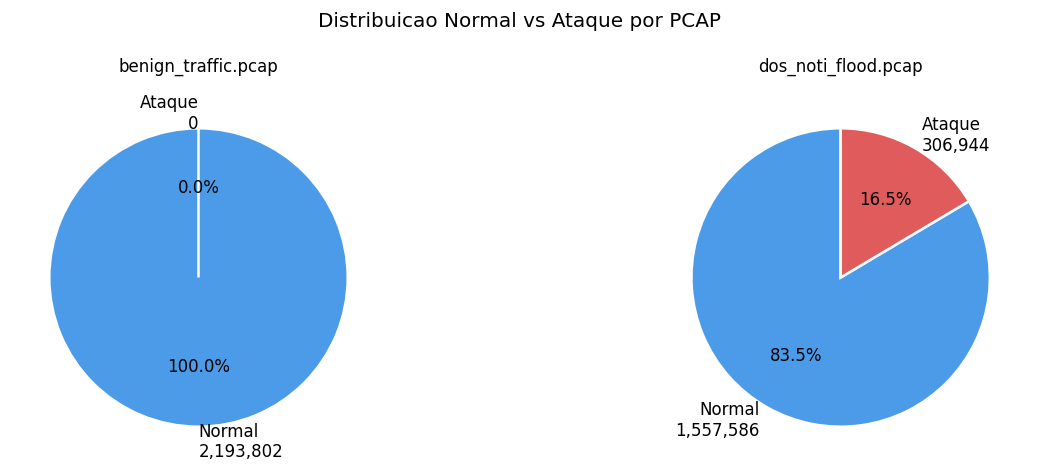

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, row in zip(axes, pcap_stats):
    vals   = [row['Normal (label=0)'], row['Ataque (label=1)']]
    colors = ['#4c9be8', '#e05c5c']
    labels = [f'Normal\n{vals[0]:,}', f'Ataque\n{vals[1]:,}']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title(row['PCAP'], fontsize=10, pad=12)

plt.suptitle('Distribuicao Normal vs Ataque por PCAP', fontsize=12)
plt.tight_layout()
plt.savefig(DOS_DIR / 'pcap_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Extracao de Features

9 features comportamentais extraidas por pacote (sem modelos de bytes):

| Feature | Descricao |
|---------|----------|
| f17 | src_packet_rate — pacotes/s do src_ip (janela 1000 pkts) |
| f18 | src_payload_diversity — payloads unicos / total (janela) |
| f15 | someip_payload_len — comprimento do payload SOME/IP |
| f01 | ip_time_interval — intervalo de tempo entre pacotes do fluxo |
| f11 | ip_length_change — variacao de tamanho IP entre pacotes |
| f13 | payload_repeat_rate — fracao dos ultimos 5 payloads identicos |
| f16 | tcpudp_len — comprimento da camada transporte |
| f08 | someip_payload_change — Hamming entre payloads consecutivos |
| f12 | tcpudp_length_change — variacao de comprimento TCP/UDP |

**Normalizacao**: Min-Max [0,1] calculada no treino, aplicada ao teste (sem data leakage).  
**Split**: 50/50 estratificado por label, `random_state=42`.

In [6]:
run_script(DOS_DIR / '01_features.py', cwd=DET_DIR)

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\dos\01_features.py


### 3.1 Dataset consolidado

In [7]:
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy').astype(int)
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy').astype(int)

n_total = len(y_train) + len(y_test)
n_ben   = (y_train==0).sum() + (y_test==0).sum()
n_dos   = (y_train==1).sum() + (y_test==1).sum()

split_data = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste', 'Total'],
    'Amostras': [len(y_train), len(y_test), n_total],
    'Normal':   [(y_train==0).sum(), (y_test==0).sum(), n_ben],
    'DoS':      [(y_train==1).sum(), (y_test==1).sum(), n_dos],
    '% DoS':    [
        f'{100*(y_train==1).sum()/len(y_train):.1f}%',
        f'{100*(y_test==1).sum()/len(y_test):.1f}%',
        f'{100*n_dos/n_total:.1f}%',
    ],
})
display(split_data.style.hide(axis='index'))
print(f'\nFeatures: {X_train.shape[1]}  |  Shape treino: {X_train.shape}  |  Shape teste: {X_test.shape}')

Conjunto,Amostras,Normal,DoS,% DoS
Treino,2029166,1875694,153472,7.6%
Teste,2029166,1875694,153472,7.6%
Total,4058332,3751388,306944,7.6%



Features: 9  |  Shape treino: (2029166, 9)  |  Shape teste: (2029166, 9)


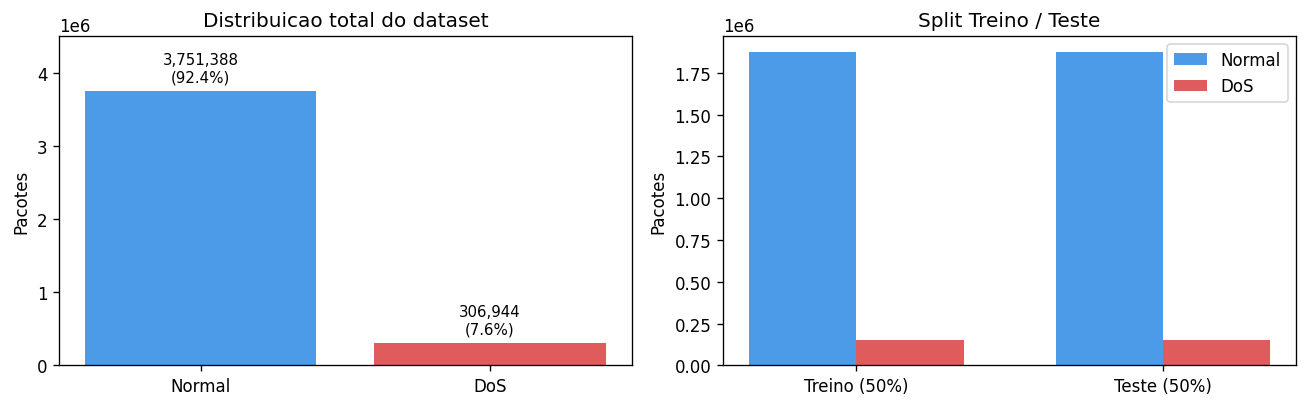

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['Normal', 'DoS'], [n_ben, n_dos], color=['#4c9be8','#e05c5c'])
axes[0].bar_label(axes[0].containers[0],
                  labels=[f'{n_ben:,}\n({100*n_ben/n_total:.1f}%)',
                          f'{n_dos:,}\n({100*n_dos/n_total:.1f}%)'],
                  padding=4, fontsize=9)
axes[0].set_title('Distribuicao total do dataset')
axes[0].set_ylabel('Pacotes')
axes[0].set_ylim(0, max(n_ben, n_dos) * 1.2)

x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, [(y_train==0).sum(), (y_test==0).sum()], w, label='Normal', color='#4c9be8')
axes[1].bar(x + w/2, [(y_train==1).sum(), (y_test==1).sum()], w, label='DoS',    color='#e05c5c')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Treino (50%)', 'Teste (50%)'])
axes[1].set_title('Split Treino / Teste')
axes[1].set_ylabel('Pacotes')
axes[1].legend()

plt.tight_layout()
plt.savefig(DOS_DIR / 'dataset_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Treinamento

**Algoritmo**: XGBoost (Extreme Gradient Boosting), classificacao binaria.  
**Parametros**: `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`, `tree_method=hist`.

In [9]:
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    subsample=1.0, colsample_bytree=1.0,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train, verbose=False)
t_train = time.perf_counter() - t0

# Inferencia — pacote unico (latencia)
single = X_test[:1]
_ = model.predict(single)
t0 = time.perf_counter()
for _ in range(1000):
    model.predict(single)
t_single_ms = (time.perf_counter() - t0) / 1000 * 1000

# Inferencia — batch
t0 = time.perf_counter()
y_pred = model.predict(X_test)
t_batch = time.perf_counter() - t0
y_prob  = model.predict_proba(X_test)[:, 1]

MODEL_DIR.mkdir(exist_ok=True)
model.save_model(str(MODEL_DIR / 'dos_classifier.json'))

print(f'Tempo de treinamento : {t_train:.2f} s')
print(f'Inferencia batch     : {t_batch:.3f} s  ({len(X_test):,} amostras)')
print(f'Latencia por pacote  : {t_single_ms:.3f} ms')
print(f'Throughput           : {len(X_test)/t_batch:,.0f} pkt/s')
print(f'Modelo salvo em      : {MODEL_DIR}/dos_classifier.json')

Tempo de treinamento : 5.33 s
Inferencia batch     : 0.744 s  (2,029,166 amostras)
Latencia por pacote  : 0.394 ms
Throughput           : 2,726,362 pkt/s
Modelo salvo em      : C:\Mestrado\SDV_Research\detection\dos\model/dos_classifier.json


## 5. Metricas de Classificacao

In [10]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn)
fnr_val = fn / (fn + tp)

summary = pd.DataFrame({
    'Metrica': [
        'Acuracia', 'Precision', 'Recall (TPR)', 'F1-Score', 'AUC-ROC',
        'Verdadeiros Negativos (TN)', 'Falsos Positivos (FP)',
        'Falsos Negativos (FN)', 'Verdadeiros Positivos (TP)',
        'Taxa Falso Positivo (FPR)', 'Taxa Falso Negativo (FNR)',
        'Tempo de treinamento', 'Latencia por pacote', 'Throughput',
    ],
    'Valor': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}', f'{auc:.6f}',
        f'{tn:,}', f'{fp:,}', f'{fn:,}', f'{tp:,}',
        f'{fpr_val:.6f}', f'{fnr_val:.6f}',
        f'{t_train:.2f} s', f'{t_single_ms:.3f} ms', f'{len(X_test)/t_batch:,.0f} pkt/s',
    ]
})
display(summary.style.hide(axis='index'))

Metrica,Valor
Acuracia,1.0000
Precision,0.9998
Recall (TPR),0.9998
F1-Score,0.9998
AUC-ROC,0.999999
Verdadeiros Negativos (TN),"1,875,670"
Falsos Positivos (FP),24
Falsos Negativos (FN),34
Verdadeiros Positivos (TP),"153,438"
Taxa Falso Positivo (FPR),0.000013


## 6. Visualizacoes

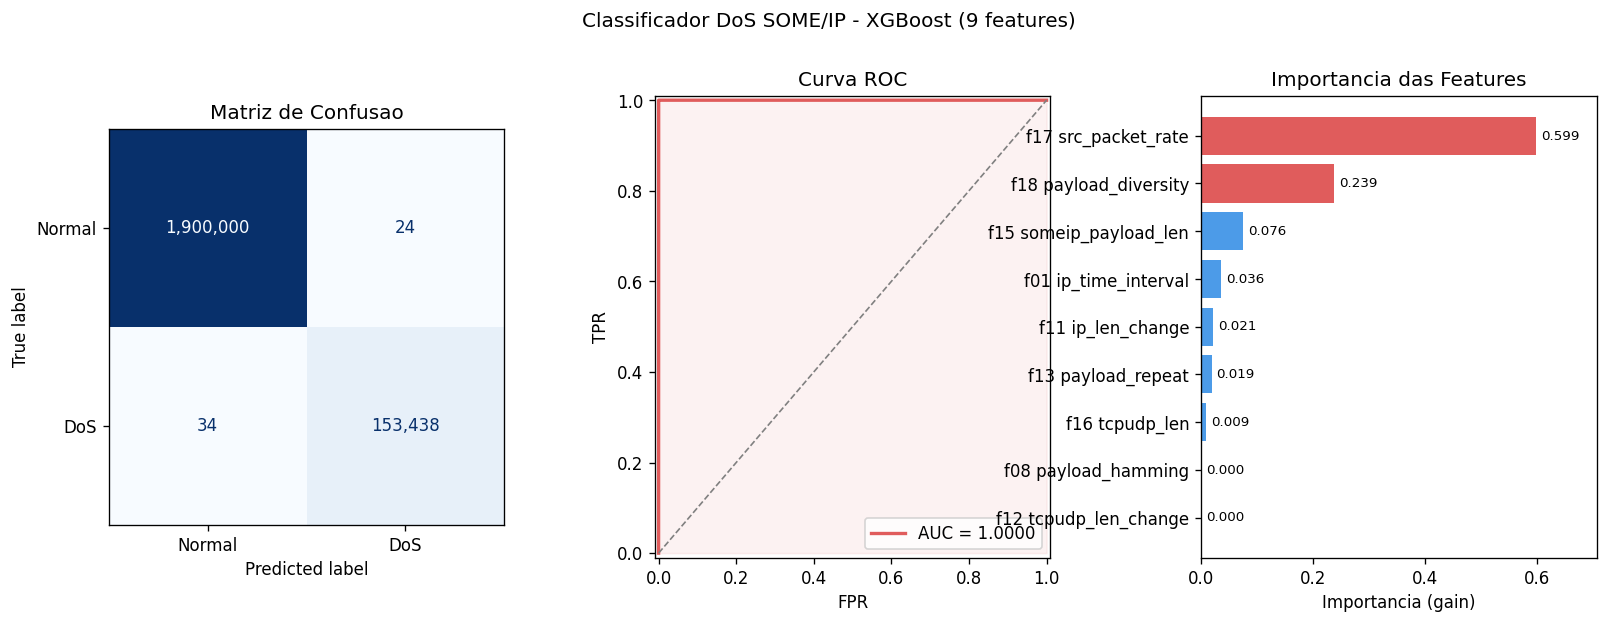

In [11]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Matriz de confusao
ax0 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'DoS'])
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title('Matriz de Confusao')
for text in disp.text_.ravel():
    v = int(float(text.get_text()))
    text.set_text(f'{v:,}')

# Curva ROC
ax1 = fig.add_subplot(gs[1])
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
ax1.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
ax1.plot([0,1],[0,1],'--', color='grey', lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# Importancia das features
ax2 = fig.add_subplot(gs[2])
imps  = model.feature_importances_
order = np.argsort(imps)
colors = ['#e05c5c' if imps[i] > 0.1 else '#4c9be8' for i in order]
bars = ax2.barh([FEAT_LABELS[i] for i in order], imps[order], color=colors)
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax2.set_xlabel('Importancia (gain)')
ax2.set_title('Importancia das Features')
ax2.set_xlim(0, max(imps) * 1.18)

plt.suptitle('Classificador DoS SOME/IP - XGBoost (9 features)', fontsize=12, y=1.02)
plt.savefig(DOS_DIR / 'results_overview.png', bbox_inches='tight', dpi=150)
plt.show()

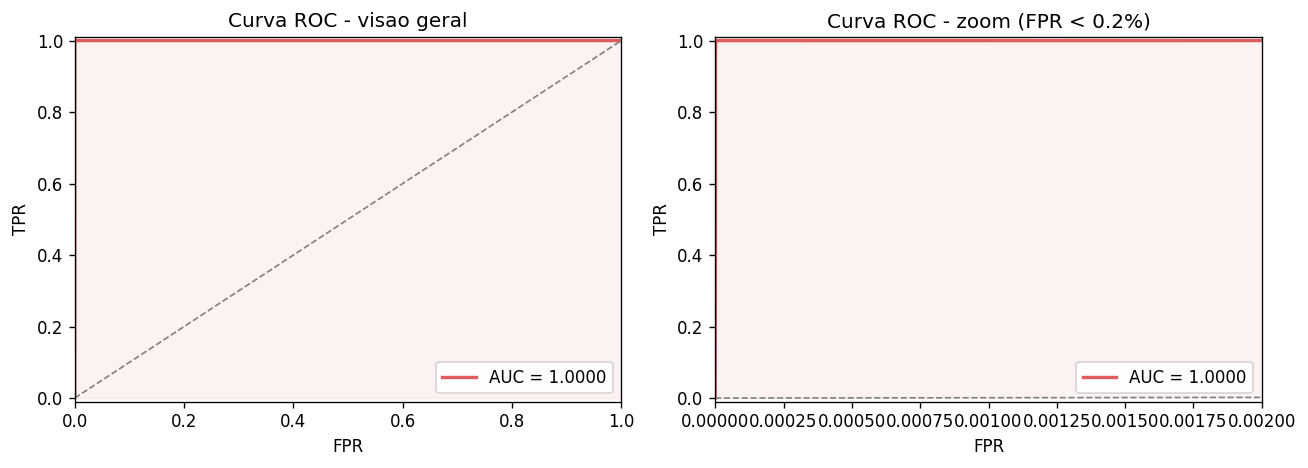

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xlim, title in zip(axes,
                            [(0, 1), (0, 0.002)],
                            ['Curva ROC - visao geral', 'Curva ROC - zoom (FPR < 0.2%)']):
    ax.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend(loc='lower right')
    ax.set_xlim(xlim); ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig(DOS_DIR / 'roc_detail.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Discussao

### Desempenho
O classificador atinge **F1=0.9998** com apenas 9 features comportamentais, sem modelos de bytes.
As duas features dominantes explicam o resultado:

- **f17 src_packet_rate (~60%)**: diferenca de duas ordens de magnitude entre o atacante
  (~5475 pkt/s) e hosts normais (<50 pkt/s) torna esta feature um discriminador quase perfeito.
- **f18 src_payload_diversity (~24%)**: o flood envia payloads repetitivos; a diversidade
  do atacante e proxima de zero, enquanto hosts normais tem alta variabilidade.

### Erros residuais
- **Falsos Positivos**: hosts normais com rajadas momentaneas de trafego elevado.
- **Falsos Negativos**: primeiros pacotes do atacante antes que a janela deslizante
  de f17 acumule taxa suficiente para superar o threshold.

### Limitacoes
| Cenario | Detectado? | Motivo |
|---------|-----------|--------|
| Flood de alta taxa (este dataset) | Sim | f17 discrimina perfeitamente |
| DoS lento (low-and-slow) | Nao | taxa por src_ip abaixo do threshold |
| DoS distribuido (varios IPs) | Nao | cada IP individual tem taxa normal |
| Rotacao de IP do atacante | Nao | janela de f17 e resetada por IP |

Em redes veiculares com enderecamento estatico (AUTOSAR), rotacao de IP e DoS
distribuido sao menos criticos, pois cada ECU tem IP fixo e conhecido.